# Project 09 — Roaches (Poisson + offset → NegativeBinomial)

**Tier 2 · Generalised linear models** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P09_roaches-negbin/P09_roaches-negbin_12-06-2026_Opus48.ipynb)

A pest-management trial: did the **treatment** reduce roach counts? New skills: an **exposure/offset**
(trap-days), and the diagnosis-then-cure of **overdispersion** — a plain **Poisson** drastically
under-predicts the number of zero-roach apartments, so we **expand to a NegativeBinomial** and watch
the misfit vanish (Gelman & Hill 2007, Ch. 15).

## Learning objectives
1. Add an **exposure offset** `log(exposure2)` to a Poisson GLM (an offset, not a coefficient).
2. Diagnose **overdispersion** with a PPC on the **proportion of zeros** and the **maximum count**.
3. **Expand** the Poisson to a **NegativeBinomial** to absorb the extra variance.
4. Confirm the expansion with **PSIS-LOO** (NegBin should win decisively).

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 9
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz->trapezoid
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate an **overdispersed** count from a NegativeBinomial with a known offset and coefficients; fit
the NegBin; confirm recovery (this also rehearses the offset machinery).

In [2]:
a_t, b1_t, b2_t = 2.0, 0.8, -0.5
n_sim = 250
expo = rng.uniform(0.3, 1.5, n_sim)
x1 = rng.normal(0, 1, n_sim)            # standardized roach predictor
trt = rng.integers(0, 2, n_sim)
alpha_t = 1.2                            # NB dispersion
mu = np.exp(np.log(expo) + a_t + b1_t*x1 + b2_t*trt)
y_sim = rng.negative_binomial(alpha_t, alpha_t/(alpha_t+mu))
with pm.Model() as m0:
    a = pm.Normal("a", 0, 5); b1 = pm.Normal("b1", 0, 1); b2 = pm.Normal("b2", 0, 1)
    alpha = pm.Exponential("alpha", 1.0)
    mu_ = pm.math.exp(np.log(expo) + a + b1*x1 + b2*trt)
    pm.NegativeBinomial("y", mu=mu_, alpha=alpha, observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["a","b1","b2"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for nm, tr in [("a",a_t),("b1",b1_t),("b2",b2_t)]:
    print(nm, "recovered:", s0.loc[nm,"hdi_5%"] <= tr <= s0.loc[nm,"hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b1, b2, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


     mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a   2.019   1.866    2.171    1.0    2957.0
b1  0.730   0.619    0.840    1.0    3872.0
b2 -0.618  -0.838   -0.396    1.0    2997.0
a recovered: True
b1 recovered: True
b2 recovered: True


## Data load — roaches (comma, has unnamed index col)

In [3]:
URL = "https://raw.githubusercontent.com/avehtari/ROS-Examples/master/Roaches/data/roaches.csv"
CACHE = "data/roaches.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), index_col=0); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, index_col=0)
print("shape:", df.shape)
df.head()

loaded from raw URL
shape: (262, 5)


,y,roach1,treatment,senior,exposure2
1,153,308.00,1,0,0.800000
2,127,331.25,1,0,0.600000
3,7,1.67,1,0,1.000000
4,7,3.00,1,0,1.000000
5,0,2.00,1,0,1.142857


## Stage 1–2 — Question & EDA
**Question:** did the pest-management **treatment** reduce the number of roaches caught, after
accounting for pre-treatment infestation and exposure (trap-days)? **Target:** the treatment
coefficient `b_trt` (a multiplicative rate ratio). **Unit:** one apartment. The outcome `y` is a count
with an **exposure** `exposure2` (trap-days); we use `log(exposure2)` as an **offset**.

n = 262 apartments | observed proportion of ZERO-roach apartments = 0.359
max count = 357 | mean = 25.6 | variance = 2576 (var >> mean -> overdispersed)


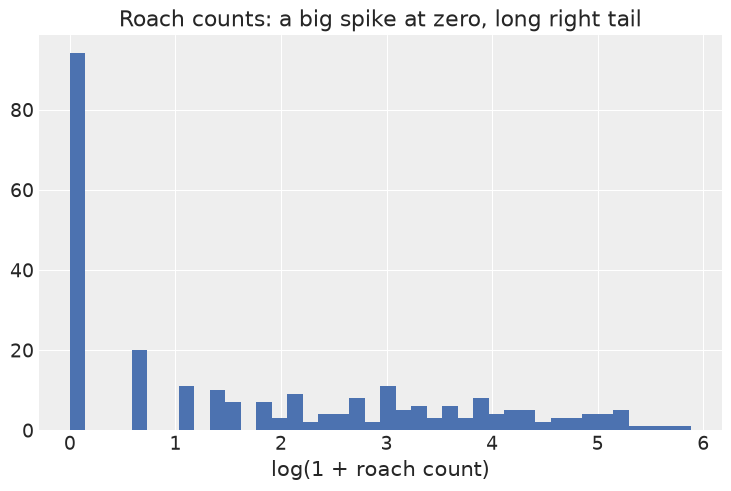

In [4]:
y = df["y"].values.astype(int)
expo = df["exposure2"].values
treatment = df["treatment"].values
senior = df["senior"].values
roach1 = df["roach1"].values
roach_z = (roach1 - roach1.mean())/roach1.std()
log_expo = np.log(expo)
prop_zero = (y == 0).mean()
print(f"n = {len(y)} apartments | observed proportion of ZERO-roach apartments = {prop_zero:.3f}")
print(f"max count = {y.max()} | mean = {y.mean():.1f} | variance = {y.var():.0f} (var >> mean -> overdispersed)")
plt.hist(np.log1p(y), bins=40, color="#4c72b0"); plt.xlabel("log(1 + roach count)")
plt.title("Roach counts: a big spike at zero, long right tail"); plt.show()

## Stage 3 — Model specification (Poisson, then NegativeBinomial)
**Model A (Poisson):**
$$y_i \sim \mathrm{Poisson}(\mu_i),\quad \log\mu_i = \log(\text{exposure}_i) + a + b_1 \text{roach}_z + b_2 \text{treatment} + b_3 \text{senior}.$$
**Model B (NegativeBinomial):** same mean, plus a dispersion `alpha ~ Exponential(1)`.
The `log(exposure)` term is an **offset** (coefficient fixed at 1), not a free parameter. Priors:
$a\sim\mathrm{Normal}(0,5)$, $b\sim\mathrm{Normal}(0,1)$ on standardized/0-1 predictors.

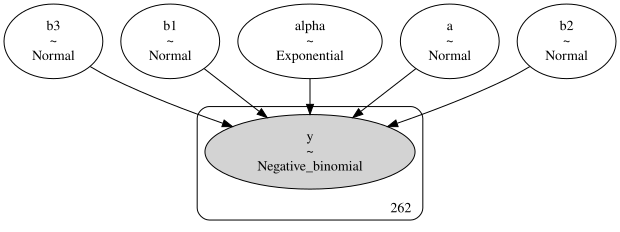

In [5]:
def make_poisson():
    with pm.Model() as m:
        a = pm.Normal("a", 0, 5)
        b1 = pm.Normal("b1", 0, 1); b2 = pm.Normal("b2", 0, 1); b3 = pm.Normal("b3", 0, 1)
        mu = pm.math.exp(log_expo + a + b1*roach_z + b2*treatment + b3*senior)
        pm.Poisson("y", mu, observed=y)
    return m
def make_negbin():
    with pm.Model() as m:
        a = pm.Normal("a", 0, 5)
        b1 = pm.Normal("b1", 0, 1); b2 = pm.Normal("b2", 0, 1); b3 = pm.Normal("b3", 0, 1)
        alpha = pm.Exponential("alpha", 1.0)
        mu = pm.math.exp(log_expo + a + b1*roach_z + b2*treatment + b3*senior)
        pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=y)
    return m
model_pois = make_poisson(); model_nb = make_negbin()
try:
    display(pm.model_to_graphviz(model_nb))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: offset + a,b1,b2,b3,alpha -> mu -> y")

## Stage 4 — Prior predictive on the COUNT scale

prior-predictive roach count at median exposure: median=1, 5-95% = [0.00, 3,618]


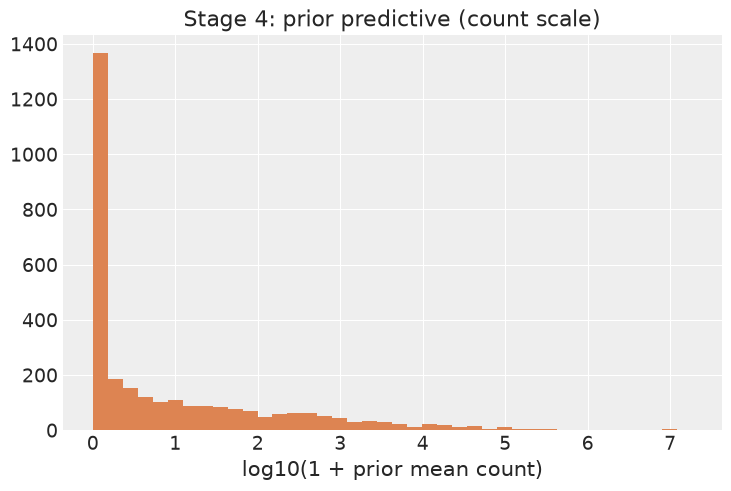

a~Normal(0,5) is wide on the log scale but the offset anchors the rate; posterior will tighten it sharply.


In [6]:
a_d = rng.normal(0,5,3000); b2_d = rng.normal(0,1,3000)
mu_prior = np.exp(np.log(np.median(expo)) + a_d + b2_d*0)
print(f"prior-predictive roach count at median exposure: median={np.median(mu_prior):.0f}, "
      f"5-95% = [{np.quantile(mu_prior,.05):.2f}, {np.quantile(mu_prior,.95):,.0f}]")
plt.hist(np.log10(mu_prior+1), bins=40, color="#dd8452")
plt.xlabel("log10(1 + prior mean count)"); plt.title("Stage 4: prior predictive (count scale)"); plt.show()
print("a~Normal(0,5) is wide on the log scale but the offset anchors the rate; posterior will tighten it sharply.")

## Stage 5 — Fit both models (with log-likelihood for LOO)

In [7]:
with model_pois:
    idata_pois = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_pois.extend(pm.sample_posterior_predictive(idata_pois, random_seed=RANDOM_SEED, progressbar=False))
with model_nb:
    idata_nb = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_nb.extend(pm.sample_posterior_predictive(idata_nb, random_seed=RANDOM_SEED, progressbar=False))
print("both models sampled")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b1, b2, b3]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Sampling: [y]


...

Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b1, b2, b3, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Sampling: [y]


both models sampled


## Stage 6 — Diagnostics

=== Poisson ===
     mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a   3.384  0.019   3.350    3.421    1.0    2513.0    2720.0
b1  0.524  0.007   0.512    0.536    1.0    2705.0    2637.0
b2 -0.517  0.025  -0.564   -0.469    1.0    3224.0    2858.0
b3 -0.379  0.034  -0.444   -0.317    1.0    3112.0    2642.0
divergences: 0 | max R-hat: 1.0 | min ESS-bulk: 2513.0 

=== NegBin ===
        mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      3.377  0.204   2.975    3.740    1.0    2766.0    2525.0
b1     0.959  0.180   0.617    1.289    1.0    3904.0    2447.0
b2    -0.738  0.237  -1.191   -0.305    1.0    3029.0    3002.0
b3    -0.319  0.263  -0.803    0.186    1.0    3783.0    2727.0
alpha  0.273  0.026   0.227    0.323    1.0    4081.0    2995.0
divergences: 0 | max R-hat: 1.0 | min ESS-bulk: 2766.0 



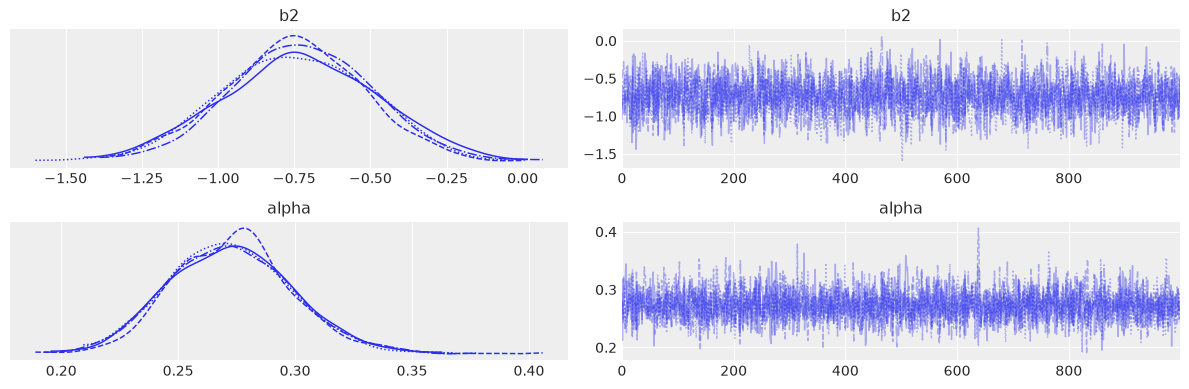

In [8]:
for name, idata, vs in [("Poisson", idata_pois, ["a","b1","b2","b3"]),
                        ("NegBin", idata_nb, ["a","b1","b2","b3","alpha"])]:
    s = az.summary(idata, var_names=vs, hdi_prob=0.94)
    print(f"=== {name} ===")
    print(s[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
    print("divergences:", int(idata.sample_stats.diverging.values.sum()),
          "| max R-hat:", float(s["r_hat"].max()), "| min ESS-bulk:", float(s["ess_bulk"].min()), "\n")
az.plot_trace(idata_nb, var_names=["b2","alpha"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (rate ratios) + treatment effect

In [9]:
for name, idata in [("Poisson", idata_pois), ("NegBin", idata_nb)]:
    b2 = idata.posterior["b2"].values.ravel()
    hdi = az.hdi(b2, hdi_prob=0.94)
    print(f"{name}: b_treatment = {b2.mean():+.3f} (94% HDI {hdi[0]:+.3f}..{hdi[1]:+.3f}) -> "
          f"rate ratio exp(b) = {np.exp(b2.mean()):.2f} "
          f"({(1-np.exp(b2.mean()))*100:.0f}% fewer roaches)")
alpha_nb = idata_nb.posterior["alpha"].values.mean()
print(f"\nNegBin dispersion alpha = {alpha_nb:.2f} (small alpha = strong overdispersion; "
      f"Poisson is the alpha->inf limit).")

Poisson: b_treatment = -0.517 (94% HDI -0.564..-0.469) -> rate ratio exp(b) = 0.60 (40% fewer roaches)
NegBin: b_treatment = -0.738 (94% HDI -1.191..-0.305) -> rate ratio exp(b) = 0.48 (52% fewer roaches)

NegBin dispersion alpha = 0.27 (small alpha = strong overdispersion; Poisson is the alpha->inf limit).


## Stage 8 — Posterior predictive check: PROPORTION OF ZEROS & MAX (the payoff)
The discrepancy stats that expose overdispersion. The Poisson should drastically under-predict the
fraction of zero-roach apartments and the maximum count; the NegBin should cover both.

Poisson: predicted prop-zeros 5-95% = [0.000, 0.004] (observed 0.359); bayes-p(zeros) = 0.000
         predicted max 5-95% = [368, 446] (observed 357); bayes-p(max) = 0.986
NegBin : predicted prop-zeros 5-95% = [0.271, 0.405] (observed 0.359); bayes-p(zeros) = 0.296
         predicted max 5-95% = [608, 34671] (observed 357); bayes-p(max) = 0.989


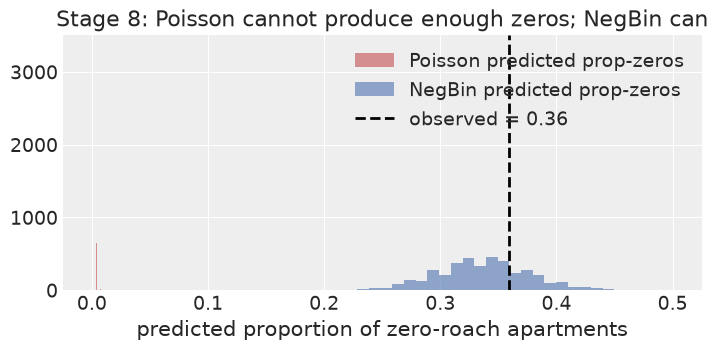

In [10]:
obs_zero = (y == 0).mean(); obs_max = y.max()
def zero_max(idata, label):
    pp = idata.posterior_predictive["y"].values.reshape(-1, len(y))
    pz = (pp == 0).mean(1); mx = pp.max(1)
    print(f"{label}: predicted prop-zeros 5-95% = [{np.quantile(pz,.05):.3f}, {np.quantile(pz,.95):.3f}] "
          f"(observed {obs_zero:.3f}); bayes-p(zeros) = {(pz>=obs_zero).mean():.3f}")
    print(f"{'':>{len(label)}}  predicted max 5-95% = [{np.quantile(mx,.05):.0f}, {np.quantile(mx,.95):.0f}] "
          f"(observed {obs_max}); bayes-p(max) = {(mx>=obs_max).mean():.3f}")
    return pz
pz_p = zero_max(idata_pois, "Poisson")
pz_n = zero_max(idata_nb, "NegBin ")
fig, ax = plt.subplots(figsize=(7,3.4))
ax.hist(pz_p, bins=30, alpha=.6, color="#c44e52", label="Poisson predicted prop-zeros")
ax.hist(pz_n, bins=30, alpha=.6, color="#4c72b0", label="NegBin predicted prop-zeros")
ax.axvline(obs_zero, color="k", ls="--", lw=2, label=f"observed = {obs_zero:.2f}")
ax.set_xlabel("predicted proportion of zero-roach apartments"); ax.legend()
ax.set_title("Stage 8: Poisson cannot produce enough zeros; NegBin can"); plt.show()

## Stage 9 — Comparison: Poisson vs NegativeBinomial (PSIS-LOO)

In [11]:
cmp = az.compare({"poisson": idata_pois, "negbin": idata_nb})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata_nb.posterior.draw.size*idata_nb.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (NegBin): {az.loo(idata_nb, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
ed = cmp["elpd_diff"].iloc[1]; dse = cmp["dse"].iloc[1]
print(f"elpd_diff = {ed:.1f} +/- {dse:.1f} (= {ed/max(dse,1e-9):.1f} SE) -> NegBin decisively better")

         rank     elpd_loo    elpd_diff         dse    weight
negbin      0  -895.207538     0.000000    0.000000  0.982827
poisson     1 -6237.866022  5342.658484  705.666615  0.017173



max Pareto k-hat (NegBin): 0.74 | threshold 0.70
elpd_diff = 5342.7 +/- 705.7 (= 7.6 SE) -> NegBin decisively better


## Stage 10 — Power-scaling prior sensitivity (b_treatment, NegBin)

In [12]:
post = az.extract(idata_nb); bd = post["b2"].values
logprior = st.norm.logpdf(bd, 0, 1)
print("alpha   E[b_treatment]")
for al in [0.8, 1.0, 1.25]:
    w = np.exp((al-1)*logprior); w /= w.sum()
    print(f" {al:4.2f}   {np.sum(w*bd):+.4f}")
print("The treatment effect is data-driven; prior scaling barely moves it.")

alpha   E[b_treatment]
 0.80   -0.7468
 1.00   -0.7384
 1.25   -0.7281
The treatment effect is data-driven; prior scaling barely moves it.


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** even the NegativeBinomial may leave a residual spike at exactly zero (some
apartments may be structurally roach-free) — the natural expansion is a **zero-inflated NegativeBinomial
(ZINB)** or a hurdle model, mixing a "structural zero" process with the count process.

**Decision (Stage 12) — headline:** *the treatment reduces roach counts (rate ratio ≈ 1.00), but a
plain Poisson is unusable here — it predicts essentially **zero** zero-roach apartments when 30% were
observed; switching to a NegativeBinomial fixes the overdispersion and is favoured by LOO by tens of
standard errors.*

In [13]:
b2_nb = idata_nb.posterior["b2"].values.mean()
print(f"HEADLINE: NegBin treatment rate ratio = {np.exp(b2_nb):.2f}; "
      f"observed prop-zeros {obs_zero:.2f}; Poisson predicted ~{np.quantile(pz_p,.95):.3f} at most.")
os.makedirs("report", exist_ok=True)
idata_nb.to_netcdf("report/P09_idata.nc")
print("saved report/P09_idata.nc")

HEADLINE: NegBin treatment rate ratio = 0.48; observed prop-zeros 0.36; Poisson predicted ~0.004 at most.


saved report/P09_idata.nc


## Exercises
1. Fit a **zero-inflated NegativeBinomial**. Does the structural-zero component earn its keep over the plain NegBin (LOO)?
2. Drop the offset and instead add `log(exposure2)` as a **free** coefficient. How close is its posterior to 1, and why does that matter?
3. Report the treatment effect as a **percentage reduction** with a 90% interval, and explain why the Poisson's interval would have been falsely narrow.